# Library Import

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [ ]:
# -- Dataset Path --
train_path = r'F:\B.Sc Engineering in ICE\All Lab\Neural Networks Sessional\Data\train'
val_path   = r'F:\B.Sc Engineering in ICE\All Lab\Neural Networks Sessional\Data\val'

# -- Data Generator --
train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(train_path, target_size=(224, 224),
                                            batch_size=32, class_mode='categorical')

class_names = list(train_data.class_indices.keys())
num_classes = len(class_names)

# Use the training class order so labels always match the model output.
val_data   = val_gen.flow_from_directory(val_path, target_size=(224, 224),
                                          batch_size=32, class_mode='categorical',
                                          classes=class_names)

print("Classes:", class_names)
print("Total classes:", num_classes)

Found 2276 images belonging to 4 classes.
Found 217 images belonging to 4 classes.
Classes: ['rose', 'sunflower', 'tulip', 'water_lily']
Total classes: 4


In [8]:


# ── ResNet50 Model ──
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Pretrained weights freeze

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()


Epoch 1/2
72/72 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.3805 - loss: 1.3330 - val_accuracy: 0.4470 - val_loss: 1.2376
Epoch 2/2
72/72 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.4354 - loss: 1.2422 - val_accuracy: 0.5300 - val_loss: 1.1595
Training Accuracy   : 50.04 %
Validation Accuracy : 53.00 %


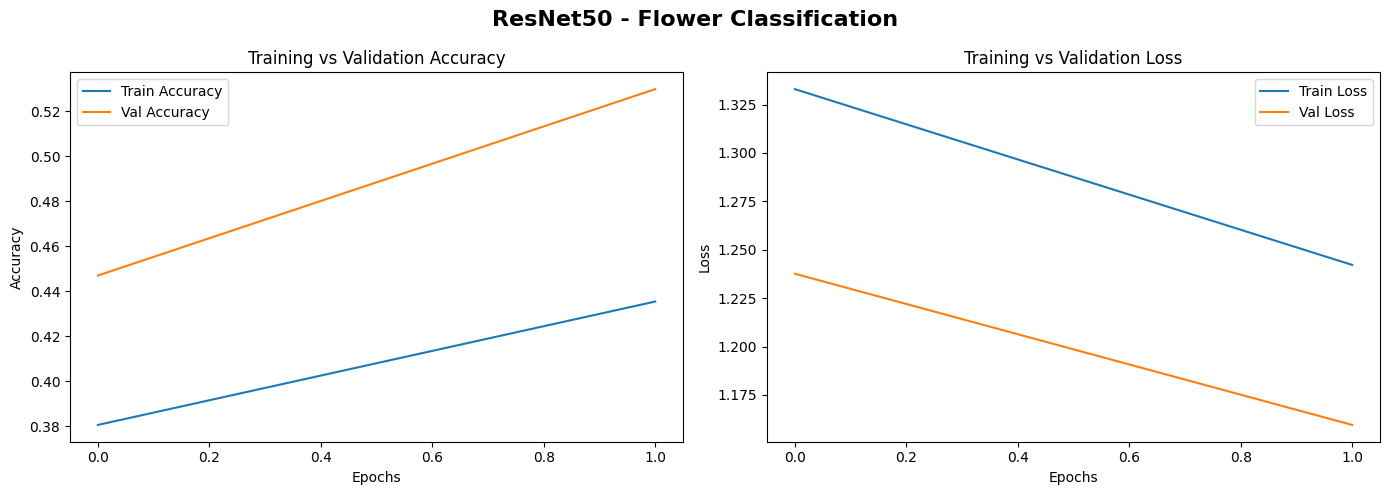

In [10]:

# ── Train ──
history = model.fit(train_data, epochs=2, validation_data=val_data, verbose=1)

# ── Accuracy ──
train_acc = model.evaluate(train_data, verbose=0)[1] * 100
val_acc   = model.evaluate(val_data,   verbose=0)[1] * 100
print(f"Training Accuracy   : {train_acc:.2f} %")
print(f"Validation Accuracy : {val_acc:.2f} %")

# ── Accuracy & Loss Curve ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()

plt.suptitle('ResNet50 - Flower Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



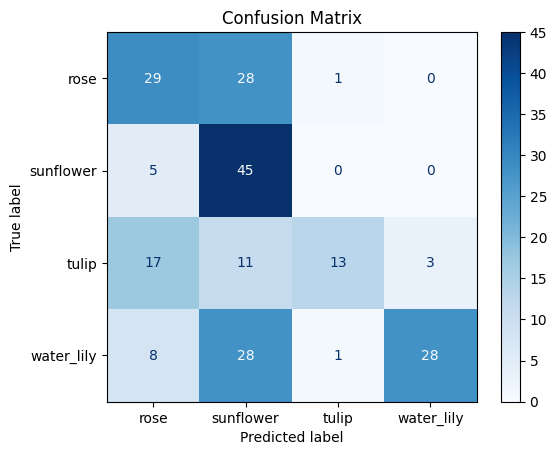


Classification Report:
              precision    recall  f1-score   support

        rose       0.49      0.50      0.50        58
   sunflower       0.40      0.90      0.56        50
       tulip       0.87      0.30      0.44        44
  water_lily       0.90      0.43      0.58        65

    accuracy                           0.53       217
   macro avg       0.67      0.53      0.52       217
weighted avg       0.67      0.53      0.52       217



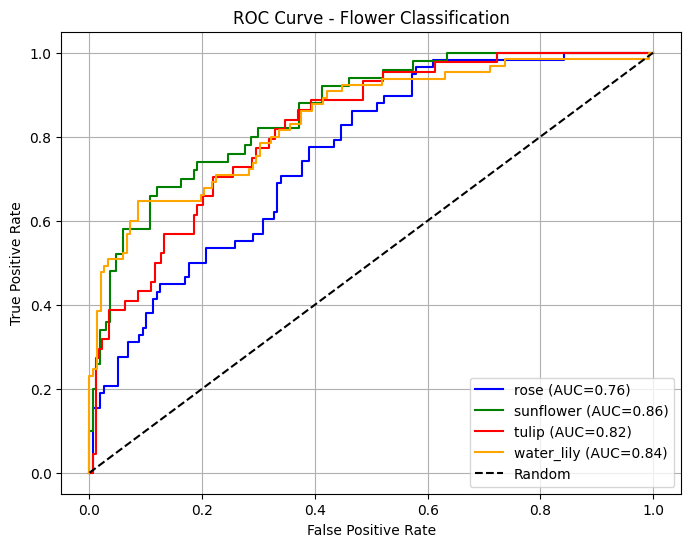

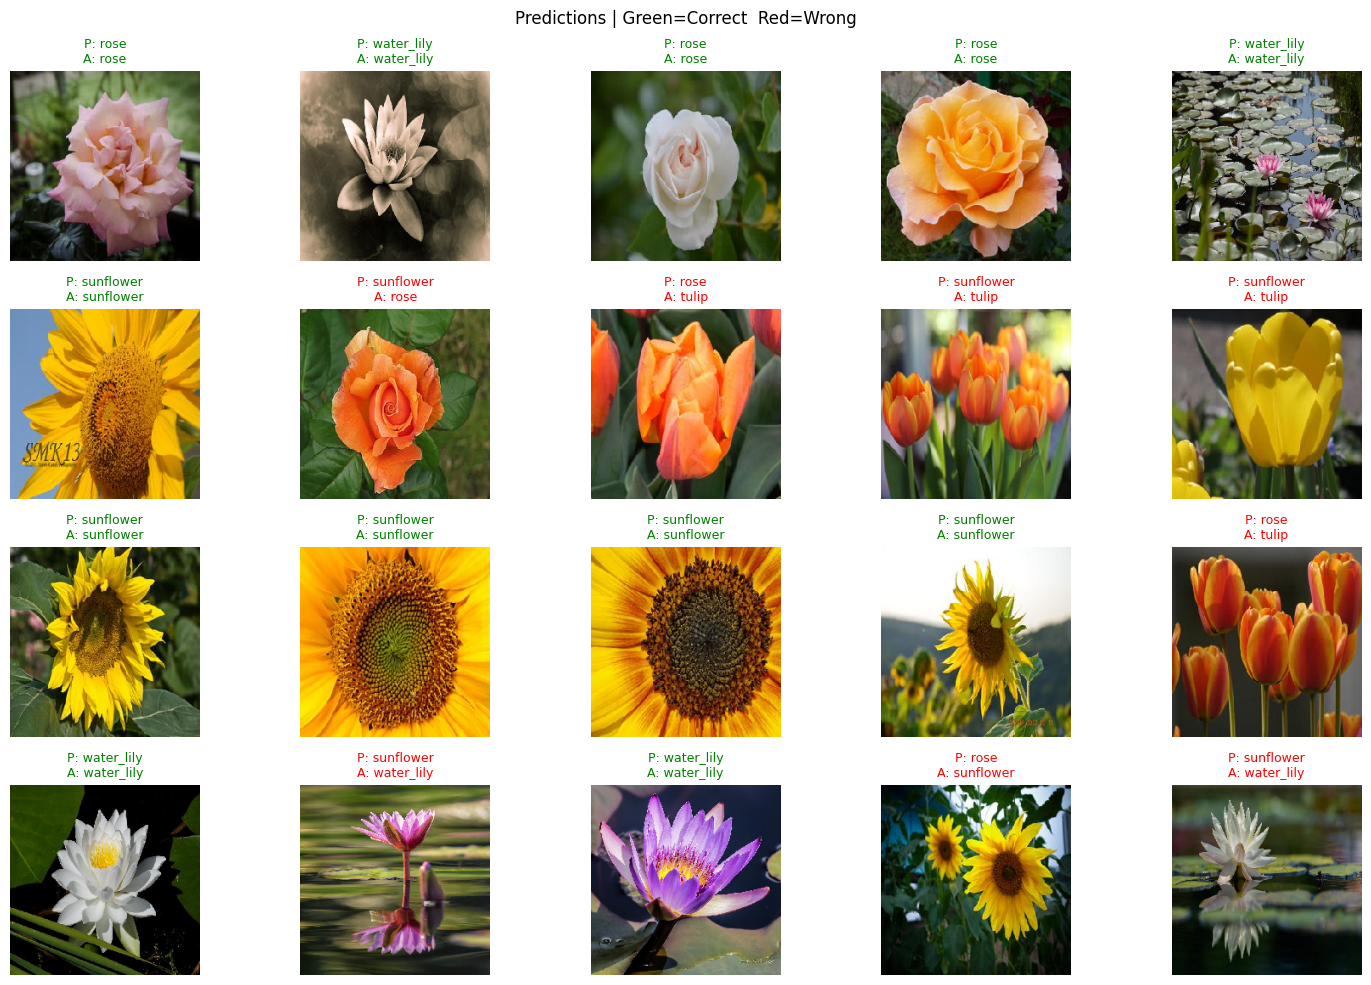

In [15]:
# ── Confusion Matrix ──
y_pred, y_true, y_score = [], [], []
val_data.reset()
for X_batch, y_batch in val_data:
    probs = model.predict(X_batch, verbose=0)
    y_score.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(y_batch, axis=1))
    if len(y_true) >= val_data.samples:
        break

y_score = np.array(y_score)
y_true  = np.array(y_true)
y_pred  = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ── Classification Report ──
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ── ROC Curve ──
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
colors = ['blue', 'green', 'red', 'orange']

plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
             label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Flower Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ── Sample Prediction ──
val_data.reset()
X_batch, y_batch = next(iter(val_data))
predictions = model.predict(X_batch, verbose=0)

plt.figure(figsize=(15, 10))
for i in range(20):
    img    = X_batch[i]
    pred   = class_names[np.argmax(predictions[i])]
    actual = class_names[np.argmax(y_batch[i])]
    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    color = 'green' if pred == actual else 'red'
    plt.title(f"P: {pred}\nA: {actual}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle('Predictions | Green=Correct  Red=Wrong', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'y_score' is not defined

<Figure size 800x600 with 0 Axes>